In [23]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
import os
from data_loader import DataLoader
from gtsam.symbol_shorthand import B, V, X
from gtsam import NavState, Pose3, Rot3, Point3
from gtsam.utils.plot import plot_pose3, set_axes_equal
from mpl_toolkits.mplot3d import Axes3D
# %matplotlib qt

In [24]:
DATA_DIR = "./full_dataset"
DataLoader.get_dir(DATA_DIR)

Data directory set to: ./full_dataset


In [25]:
# read sensor data
imu_file =  "imu_adis_ros.csv"
dvl_file =  "dvl_linkquest.csv"
depth_file =  "depth_sensor.csv"
odom_file = "odometry.csv"

imu = DataLoader.read_imu(imu_file)
dvl = DataLoader.read_dvl(dvl_file)
depth = DataLoader.read_depth(depth_file)
odom = DataLoader.read_odom(odom_file)

# print(imu)

In [26]:
# time synchronization
start_time = imu['time'][0]

# print(f"Start time: {start_time}")
# offeset all timestamps to start from zero
imu['time'] -= start_time
dvl['time'] -= start_time
depth['time'] -= start_time
odom['time'] -= start_time

# show new time
print(f"New start time: {imu['time'][0]}")
print(f"New end time: {imu['time'][-1]}")

# convert nanoseconds to seconds
imu['time'] /= 1e9
dvl['time'] /= 1e9
depth['time'] /= 1e9
odom['time'] /= 1e9

# print
print(f"IMU time range: {imu['time'][0]} to {imu['time'][-1]}")

New start time: 0.0
New end time: 1955073564672.0
IMU time range: 0.0 to 1955.073564672


In [27]:
# state initialization
# biases
accBias = np.array([0.067, 0.115, 0.32])
gyroBias = np.array([0.067, 0.115, 0.32])
bias = gtsam.imuBias.ConstantBias(accBias, gyroBias)

# set gravity
pim_params = gtsam.PreintegrationParams.MakeSharedU(9.81)

# Some arbitrary noise sigmas
gyro_sigma = 1e-3
accel_sigma = 1e-3
I_3x3 = np.eye(3)
pim_params.setGyroscopeCovariance(gyro_sigma**2 * I_3x3)
pim_params.setAccelerometerCovariance(accel_sigma**2 * I_3x3)
pim_params.setIntegrationCovariance(1e-7**2 * I_3x3)

# preintegrate imu measurements
pim = gtsam.PreintegratedImuMeasurements(pim_params, bias)

# Noise models for factors
priorNoise = gtsam.noiseModel.Isotropic.Sigma(6, 0.1)
velNoise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)

In [28]:
def main_loop(graph, initial):
    # add prior initial node from odometry
    init_pose = Pose3(
        Rot3.Quaternion(
            odom['qw'][0],
            odom['qx'][0],
            odom['qy'][0],
            odom['qz'][0],
        ),
        Point3(
            odom['x'][0],
            odom['y'][0],
            odom['z'][0],
        )
    )

    init_vel = Point3(0.0, 0.0, 0.0)

    init_state = NavState(init_pose, init_vel)

    # add initial graph
    graph.push_back(gtsam.PriorFactorPose3(X(0), init_state.pose(), priorNoise)) # position
    graph.push_back(gtsam.PriorFactorVector(V(0), init_state.velocity(), velNoise)) # velocity

    # add initial values
    initial.insert(X(0), init_state.pose())
    initial.insert(V(0), init_state.velocity())
    initial.insert(B(0), bias)
    # enumerate imu data
    # set last time
    last_time = imu['time'][0]
    # set initial state
    # prev_state = initial
    prev_state = init_state

    key_index = 0

    for i in range(1, len(imu['time'])):
    # for i in range(1, 100):
        # get measurement data at index i
        dt = imu['time'][i] - imu['time'][i - 1]
        # print(f"dt: {dt}")
        measured_acc = np.array([
            imu['ax'][i],
            imu['ay'][i],
            imu['az'][i],
        ])
        # print(f"measured_acc: {measured_acc}")
        measured_omg = np.array([
            imu['omega_x'][i],
            imu['omega_y'][i],
            imu['omega_z'][i],
        ])
        # print(f"measured_omg: {measured_omg}")

        # integrate measurement
        pim.integrateMeasurement(measured_acc, measured_omg, dt)

        freq = 3.0 # Hz (DVL freq)
        threshold = 1.0 / freq
        current_time = imu['time'][i]
        if current_time - last_time  >= threshold:
            # Create IMU factor every threshold seconds
            factor = gtsam.ImuFactor(X(key_index), V(key_index), X(key_index + 1), V(key_index + 1), B(0), pim)
            graph.push_back(factor)

            # get nav state
            actual_state = pim.predict(prev_state, bias)

            # insert initial estimate
            initial.insert(X(key_index + 1), actual_state.pose())
            initial.insert(V(key_index + 1), actual_state.velocity())
            key_index += 1
            print(f"Inserted key index: {key_index}")
            
            pim.resetIntegration()
            prev_state = actual_state # for next time

            last_time = current_time # for next time
        
        

In [29]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

# add prior initial node from odometry
# init_pose = Pose3(
#     Rot3.Quaternion(
#         odom['qw'][0],
#         odom['qx'][0],
#         odom['qy'][0],
#         odom['qz'][0],
#     ),
#     Point3(
#         odom['x'][0],
#         odom['y'][0],
#         odom['z'][0],
#     )
# )

# init_vel = Point3(0.0, 0.0, 0.0)

# init_state = NavState(init_pose, init_vel)

# # add initial graph
# graph.push_back(gtsam.PriorFactorPose3(X(0), init_state.pose(), priorNoise)) # position
# graph.push_back(gtsam.PriorFactorVector(V(0), init_state.velocity(), velNoise)) # velocity

# # add initial values
# initial.insert(X(0), init_state.pose())
# initial.insert(V(0), init_state.velocity())
# initial.insert(B(0), bias)

In [30]:
main_loop(graph, initial) 

Inserted key index: 1
Inserted key index: 2
Inserted key index: 3
Inserted key index: 4
Inserted key index: 5
Inserted key index: 6
Inserted key index: 7
Inserted key index: 8
Inserted key index: 9
Inserted key index: 10
Inserted key index: 11
Inserted key index: 12
Inserted key index: 13
Inserted key index: 14
Inserted key index: 15
Inserted key index: 16
Inserted key index: 17
Inserted key index: 18
Inserted key index: 19
Inserted key index: 20
Inserted key index: 21
Inserted key index: 22
Inserted key index: 23
Inserted key index: 24
Inserted key index: 25
Inserted key index: 26
Inserted key index: 27
Inserted key index: 28
Inserted key index: 29
Inserted key index: 30
Inserted key index: 31
Inserted key index: 32
Inserted key index: 33
Inserted key index: 34
Inserted key index: 35
Inserted key index: 36
Inserted key index: 37
Inserted key index: 38
Inserted key index: 39
Inserted key index: 40
Inserted key index: 41
Inserted key index: 42
Inserted key index: 43
Inserted key index: 

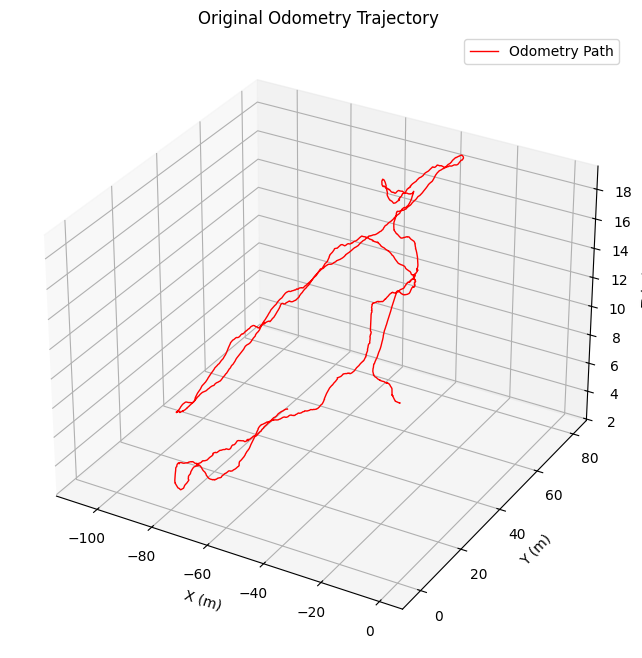

In [31]:
# plot original imu trajectory
def plot_ori_odom():
    xs, ys, zs = [], [], []
    for i in range(len(imu['time'])):
        xs.append(odom['x'][i])
        ys.append(odom['y'][i])
        zs.append(odom['z'][i])
    
    fig = plt.figure(2, figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(xs, ys, zs, '-r', linewidth=1, label="Odometry Path")
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title("Original Odometry Trajectory")
    ax.legend()
    plt.show()

plot_ori_odom()

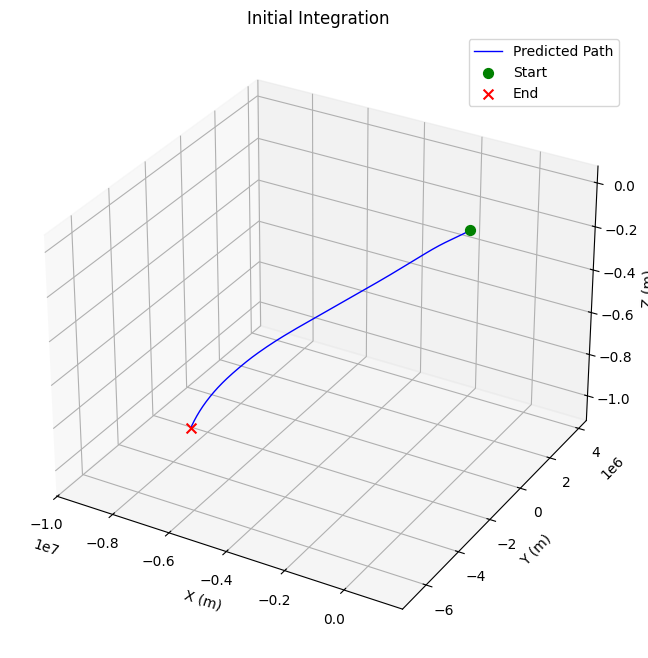

In [ ]:
def plot_trajectory_fast(values: gtsam.Values, 
                         title: str = "Trajectory", 
                         fignum: int = 1, 
                         show: bool = True):
    # 1. Create/Get the figure
    fig = plt.figure(fignum, figsize=(10, 8))
    
    # 2. CLEAR the figure to remove any existing 2D axes
    fig.clf() 
    
    # 3. Explicitly add a 3D subplot
    ax = fig.add_subplot(111, projection='3d')
    
    xs, ys, zs = [], [], []
    i = 0
    
    # Extract data
    while values.exists(X(i)):
        pose = values.atPose3(X(i))
        p = pose.translation()
        
        xs.append(p[0])
        ys.append(p[1])
        zs.append(p[2])
        i += 1
    
    if len(xs) == 0:
        print("No poses found!")
        return

    # Plot the path line
    ax.plot(xs, ys, zs, '-b', linewidth=1, label="Predicted Path")
    
    # Mark Start (Green) and End (Red)
    # Note: On a 3D axis, scatter accepts (x, y, z)
    ax.scatter(xs[0], ys[0], zs[0], c='g', marker='o', s=50, label="Start")
    ax.scatter(xs[-1], ys[-1], zs[-1], c='r', marker='x', s=50, label="End")

    # Labels and Title
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(title)
    ax.legend()
    
    # Equal Aspect Ratio (Try/Except in case utils are missing)
    try:
        gtsam.utils.plot.set_axes_equal(fignum)
    except:
        pass
        
    if show:
        plt.show()

# Run it
plot_trajectory_fast(initial, title="Initial Integration", fignum=1)

In [33]:
# print(initial)

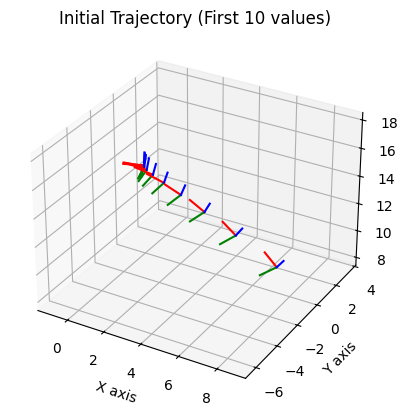

In [34]:
def plot_trajectory(values: gtsam.Values,
                    title: str = "Estimated Trajectory",
                    fignum: int = 1,
                    limit: int = 100, # <--- Limit parameter
                    show: bool = False):
    i = 0
    # Run while key exists AND i is less than limit
    while values.exists(X(i)) and i < limit:
        pose_i = values.atPose3(X(i))
        plot_pose3(fignum, pose_i, 1)
        i += 1
        
    plt.title(f"{title} (First {i} values)")

    gtsam.utils.plot.set_axes_equal(fignum)

    plt.ioff()

    if show:
        plt.show()

# Usage: Plot only the first 100 values
plot_trajectory(initial, title="Initial Trajectory", fignum=7, limit=10, show=True)
